In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Chua Circuit Computation Notebook

## Introduction

The **Chua Circuit** provides an answer to the question--how simple can a physical system be while exhibiting chaos (Chua, 1992). It is a **nonlinear dynamical system** described by a set of coupled ordinary differential equations (ODE). The objective of this notebook is to approximate its trajectory numerically, and verify that the results are consistent with theoretical explanations.

## Theory: The Chua System

The normalized Chua system is defined by

$$
\dot{x}=\alpha(y-x-h(x))
\\
\dot{y}=x-y+z
\\
\dot(z)=-\beta y
$$

wherein the piecewise-linear nonlinearity:

$$
h(x)=m_1x+\frac{1}{2}(m_0-m_1)(|x+1|-|x-1|)
$$

The state vector is

$$
\mathbf{x}(t) = \begin{bmatrix} x(t) \\ y(t) \\ z(t) \end{bmatrix} \in \mathbb{R}^3
$$

As such, the change in $\mathbf{x}$ may be defined as:

$$
\dot{\mathbf{x}} = \mathbf{f(x)}
$$

where $x$, $y$, $z$ are normalized versions of the two capacitor voltages and the inductor current ($v_1$, $v_2$, $i_L$)

This normalized formulation is standard in the study of the Chua system and is widely used in the literature (Matsumoto, 1984; Strogatz, 2015).

## Numerical Method: Runge-Kutta 4(5)

Considering the initial value problem
$$
\dot{\mathbf{x}}=\mathbf{f}=(t,\ \mathbf{x}),\ \dot{\mathbf{x}}(t_0)=\mathbf{x}_0
$$
where for the Chua circuit,
$$
\mathbf{x}(t) = \begin{bmatrix} x(t) \\ y(t) \\ z(t) \end{bmatrix} \in \mathbb{R}^3
$$.
No closed-form solutions exist in the chaotic regime, thus, the trajectory **must** be approximated numerically.

### Taylor Series

Before explaining Runge-Kutta, we must first understand the core-**the Taylor Series**.

The exact solution satisfies
$$
\mathbf{x}(t+h)=\mathbf{x}(t)+h\dot{\mathbf{x}}(t)+\frac{h^2}{2}\ddot{x}(t)+\mathcal{O}(h^3)
$$
Now, using the previously mentioned solution of $\dot{\mathbf{x}}=\mathbf{F}(\mathbf{x})$, we can rewrite it as
$$
\mathbf{x}(t+h)=\mathbf{x}(t)+h\mathbf{f}(\mathbf{x}(t))+\frac{h^2}{2}\frac{d}{dt}\mathbf{F}(\mathbf{x}{t})+...
$$
This difficulty arises because higher-order terms require repeated differentiation:
$$
\frac{d}{dt}\mathbf{f}(\mathbf{x})=J(\mathbf{x})\mathbf{f}(\mathbf{x});\ J=\text{ Jacobian}
$$
Thus, computing higher-order Taylor terms requires evaluating Jacobians and higher derivatives repeatedly, which quickly becomes computationally expensive (Butcher, 2016).

Runge-Kutta methods approximate these higher-order terms using multiple evaluations of $F$ instead of explicitly computing derivatives.

### Explicit Euler

Now, if the Taylor Series is truncated after the first term, s.t.
$$
\mathbf{x}_{n+1}=\mathbf{x}_n+h\mathbf{f}(\mathbf{x}_n)
$$
This is known as the **Euler Method**

This has a local error of $\mathcal{O}(h^2)$ and a global error of $\mathcal{O}(h)$.

However, this also fails, as the Chua system is chaotic
$$
||\delta\mathbf{x}(t)||\approx||\delta\mathbf{x}(0)||e^{\lambda t},\ \lambda>0
$$
which means that small errors will grow exponentially, leading to large truncation errors.

This exponential divergence corresponds to a positive Lyapunov exponent, which is a defining feature of chaotic systems (Ott, 2002).

### Implicit Euler

If explicit methods don't work, an implicit method may work here.

**Implicit Euler**, given by
$$
\mathbf{x}_{n+1} = \mathbf{x}_n + h\,\mathbf{f}(\mathbf{x}_{n+1})
$$
has the next state appearing on both sides, thus, $\mathbf{x}_{n+1}$ must be solved at each step. This improves stability in **stiff** systems, with errors no longer exploding.

However, for a chaotic system like Chua, solving $\mathbf{x}_{n+1}$ continuously is computationally expensive. It also introduces numerical damping, leading to a distorted attractor structure and a lower accuracy overall.

### Runge-Kutta

Upon evaluating explicit and implicit Euler methods, we find major issues in both. Explicit Euler causes truncation errors, and implicit Euler is computationally expensive and introduces numerical damping. Thus, we move our eyes over to Runge-Kutta. 

Runge-Kutta methods may be either explicit or implicit, and in this case, an **explicit Runge-Kutta** method is used, as **implicit** methods have the same issue as Euler-expensive computation power.

They sample the slope multiple times, essentially approximating the solution at $t_{n+1}=t_n+h$ through multiple evaluations of vector field. Each stage acts as a weighted sample of the vector field, allowing the method to match the Taylor expansion up to order p without explicitly computing derivatives.
$$
\mathbf{x}_{n+1}=\mathbf{x}_n+h\sum^s_{i=1}b_ik_i
$$
wherein each stage is
$$
\mathbf{k}_i=\mathbf{F}(t_n+c_ih,\ \mathbf{x}_n+h\sum^{i-1}_{j=1}a_{ij}k_j)
$$
This approximates the Taylor expansion while not explicitly computing for higher derivatives.

For method of order $p$
$$
\text{local\ truncation\ error}\approx \mathcal{O}(h^{p+1}),\ \text{global\ error}\approx \mathcal{O}(h^p)
$$

### Which RK Method Do We Use?

Runge-Kutta has multiple methods of which we can choose, with the difference being how many slope samples $h$ it uses. For example, RK1, or Euler's Method, uses 1 sample. The more samples used, the closer the error is to $0$.

As such, this notebook uses RK45, of order $5(4)$, implemented in `solve_ivp`. This computes two approximations at each step,
$$
\mathbf{x}^{(5)},\ \mathbf{x}^{(4)}
$$
where $\mathbf{x}^{(5)}$ is a 5th-order solution, and $\mathbf{x}^{(4)}$ is a 4th-order solution.

The difference between these two is an estimate of the local truncation error
$$
\varepsilon=||\mathbf{x}^{(5)}-\mathbf{x}^{(4)}||
$$
and $\varepsilon$ is used to adapt the step size, which is necessary as small numerical errors grow exponentially.
$$
h_{new}=h(\frac{\text{tol}}{\varepsilon})^{1/5}
$$
Furthermore, it provides order $p=5$ accuracy
$$
\varepsilon \approx \mathcal{O}(h^5)
$$

Lower methods, like RK1, RK2, and RK4, typically introduce large numerical errors, with it usually diverging from theory. Higher methods, like RK8, take too much computing power.

RK45 provides an optimal balance between accuracy and computational cost:
- The 5th-order solution provides high accuracy
- The embedded 4th-order solution estimates error
- Adaptive step sizing ensures efficiency while controlling error growth

This is especially important for chaotic systems, where small errors grow exponentially (Dormand & Prince, 1980; Hairer et al., 1993).

### Why not Sympletic Integrators?

Sympletic Integrators are used and designed for Hamiltonian systems,
$$
\dot{\mathbf{q}}=\frac{\partial H}{\partial \mathbf{p}},\ \dot{\mathbf{p}}=\frac{\partial H}{\partial \mathbf{q}}
$$
and preserves phase-space volume
$$
\det(J) = 1
$$
$$
\nabla \cdot \mathbf{p} = 0
$$

For the Chua system,
$$
\nabla \cdot \mathbf{p} <0
$$
implying that **phase-space volume contracts**, meaning trajectories may collapse onto an attractor.

As such,
$$
\mathbf{x}(t)\rightarrow \mathcal{A}
$$
where $\mathcal{A}=$ attractor.

As such, sympletic methods enforce $\det(J)=1$, while Chua requies $\det(J)<1$. Meaning that a sympletic integrator would preserve incorrect geometry.

## Implementation: Setting Up Parameters, RK45, and Defining the Model

In [2]:
# Parameters chosen to reproduce double-scroll attractor
ALPHA = 15.6
BETA = 28.0
M0 = -1.143
M1 = -0.714

T_START = 0.0
T_END = 200.0
NUM_POINTS = 30_000
T_SPAN = (T_START, T_END)
T_EVAL = np.linspace(T_START, T_END, NUM_POINTS)
TRANSIENT_CUT = 5_000


# Defines the Chua diode's piecewise-linear function, which models the nonlinear resistor in the circuit.
def chua_diode(x: np.ndarray | float, m0: float, m1: float) -> np.ndarray | float:
    """
    PHYSICS INTERPRETATION: 
    This function defines the 'Chua Diode', the source of the system's nonlinearity. 
    It acts as an active resistor: it pumps energy into the circuit within the 
    [-1, 1] range (negative resistance region), which forces the system to 
    spiral outward. Once the trajectory hits the outer regions, it behaves 
    like a standard resistor, pulling the trajectory back. This push-pull 
    mechanism creates the chaotic 'double-scroll' attractor.
    """
    return m1 * x + 0.5 * (m0 - m1) * (np.abs(x + 1) - np.abs(x - 1))

# Defines the system of ODEs representing the Chua circuit. It takes the current state and parameters, and returns the derivatives.
def chua_circuit(
    t: float,
    state: np.ndarray,
    alpha: float,
    beta: float,
    m0: float,
    m1: float,
) -> list[float]:
    """Return the derivatives for the normalized Chua system."""
    x, y, z = state
    dx_dt = alpha * (y - x - chua_diode(x, m0, m1))
    dy_dt = x - y + z
    dz_dt = -beta * y
    return [dx_dt, dy_dt, dz_dt]

def solve_chua(
    initial_state: list[float],
    method: str = "RK45",
    rtol: float = 1e-8,
    atol: float = 1e-10,
) -> tuple[np.ndarray, np.ndarray]:
    """Solve the Chua system and return time values and state trajectories."""
    solution = solve_ivp(
        chua_circuit,
        T_SPAN,
        initial_state,
        t_eval=T_EVAL,
        method=method,
        rtol=rtol,
        atol=atol,
        args=(ALPHA, BETA, M0, M1),
    )
    return solution.t, solution.y

def remove_transient(
    sol: np.ndarray,
    cut: int = TRANSIENT_CUT,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Remove the initial transient from a trajectory."""
    return sol[0][cut:], sol[1][cut:], sol[2][cut:]

### Main Numerical Solution

In [3]:
initial_state = [0.7, 0.0, 0.0]

t, sol = solve_chua(initial_state)
x, y, z = sol
x_cut, y_cut, z_cut = remove_transient(sol)

## Results: Computations and Visualizations

### Nonlinearity

This plot shows the piecewise-linear Chua diode function $h(x)$, aka the source of nonlinearity within the system

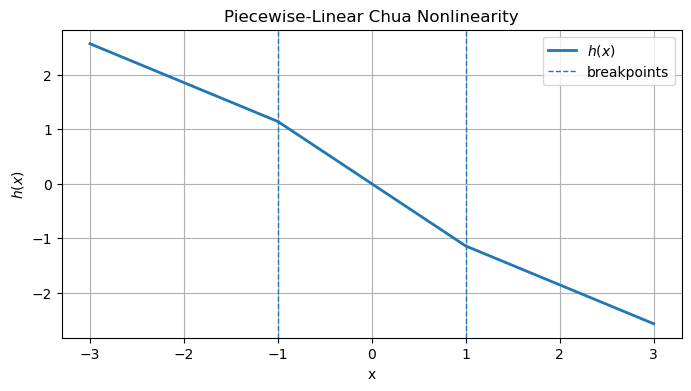

In [4]:
x_vals = np.linspace(-3.0, 3.0, 1_000)
h_vals = chua_diode(x_vals, M0, M1)

plt.figure(figsize=(8, 4))

plt.plot(
    x_vals,
    h_vals,
    linewidth=2,
    label=r"$h(x)$",
)

plt.axvline(
    -1,
    linestyle="--",
    linewidth=1,
    label="breakpoints",
)

plt.axvline(
    1,
    linestyle="--",
    linewidth=1,
)

plt.title("Piecewise-Linear Chua Nonlinearity")
plt.xlabel("x")
plt.ylabel(r"$h(x)$")

plt.grid(True)
plt.legend()

plt.show()

### Time Series

If the dynamics are chaotic, time series should be bounded, and not periodic.

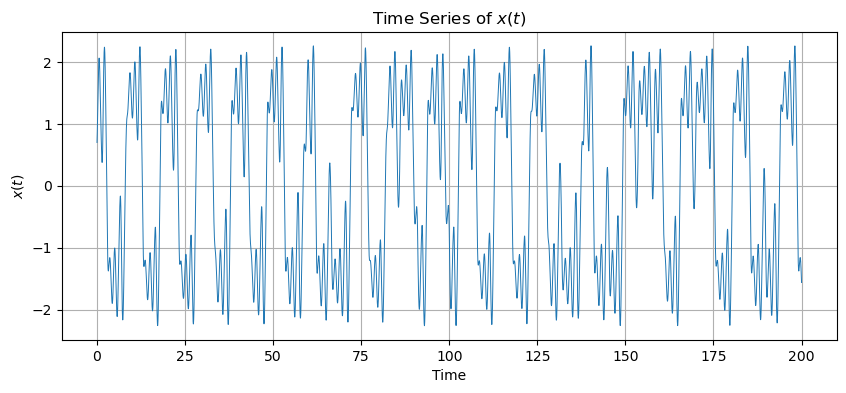

In [5]:
plt.figure(figsize=(10, 4))

plt.plot(
    t,
    x,
    linewidth=0.7,
)

plt.title("Time Series of $x(t)$")
plt.xlabel("Time")
plt.ylabel(r"$x(t)$")

plt.grid(True)

plt.show()

The irregular yet bounded behavior indicates non-periodic dynamics confined to a finite region, consistent with chaotic attractors.

### 3D Attractor After Transient Removal

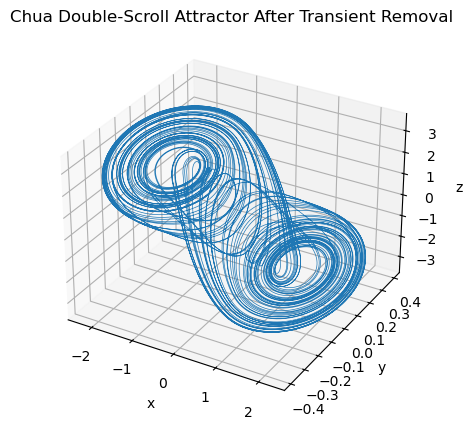

In [6]:
x_cut, y_cut, z_cut = remove_transient(sol)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    x_cut,
    y_cut,
    z_cut,
    linewidth=0.5,
)

ax.set_title("Chua Double-Scroll Attractor After Transient Removal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

The double-scroll structure confirms the presence of a strange attractor, where trajectories switch between two unstable equilibrium regions.

### 2D Projections to Inspect Topology

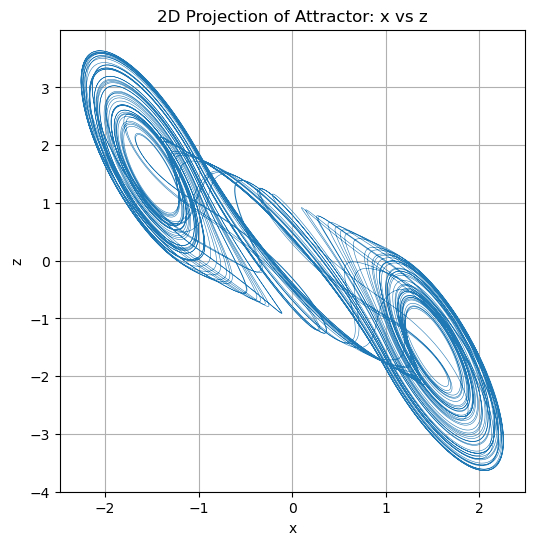

In [7]:
plt.figure(figsize=(6, 6))

plt.plot(
    x_cut,
    z_cut,
    linewidth=0.4,
)

plt.title("2D Projection of Attractor: x vs z")
plt.xlabel("x")
plt.ylabel("z")

plt.grid(True)

plt.show()

The linear growth in log-scale indicates exponential divergence, confirming a positive Lyapunov exponent.

## Validation: Testing the Solution

The following tests have two main purposes:
1. To verify the correctness of numerical implementation.
2. To ensure that the observed behavior matches the theoretical expectations of chaotic systems.

### Short-Time Agreement of Nearby Trajectories

If two initial condiitons are close, RK45 should resolve it accurately enough that trajectories initially remain close,

$$
||\mathbf{x}_1(t)-\mathbf{x}_2(t)||\approx 0
$$

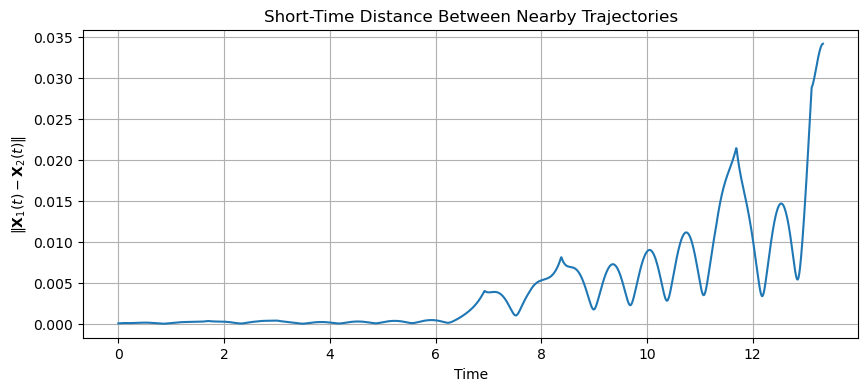

Maximum short-time distance: 3.4208e-02


In [8]:
t1, sol1 = solve_chua([0.7, 0.0, 0.0])
t2, sol2 = solve_chua([0.7001, 0.0, 0.0])

x1, y1, z1 = sol1
x2, y2, z2 = sol2

distance = np.sqrt(
    (x1 - x2) ** 2
    + (y1 - y2) ** 2
    + (z1 - z2) ** 2
)

window = 2_000

plt.figure(figsize=(10, 4))

plt.plot(
    t1[:window],
    distance[:window],
)

plt.title("Short-Time Distance Between Nearby Trajectories")
plt.xlabel("Time")
plt.ylabel(r"$\|\mathbf{X}_1(t)-\mathbf{X}_2(t)\|$")

plt.grid(True)

plt.show()

print(
    f"Maximum short-time distance: "
    f"{distance[:window].max():.4e}"
)

### When does the Trajectory diverge from a High-Accuracy Reference Solution

RK45 is an approximation, and errors can accumulate over time. As such, a test to find at which point does it stop agreeing is needed.

But, the Chua system has no closed-form theoretical solution, so using a higher-order method-DOP853-with stricter tolerances will be used. 

In [9]:
# Reference solution: stricter, higher-order method
t_ref, sol_ref = solve_chua(
    [0.7, 0.0, 0.0],
    method="DOP853",
    rtol=1e-12,
    atol=1e-14,
)

# RK45 solution being tested
t_rk45, sol_rk45 = solve_chua(
    [0.7, 0.0, 0.0],
    method="RK45",
    rtol=1e-8,
    atol=1e-10,
)

# Distance between RK45 and reference solution
rk45_error = np.sqrt(
    (sol_rk45[0] - sol_ref[0]) ** 2
    + (sol_rk45[1] - sol_ref[1]) ** 2
    + (sol_rk45[2] - sol_ref[2]) ** 2
)

# Define drift threshold
drift_threshold = 1e-2

drift_indices = np.where(rk45_error > drift_threshold)[0]

if drift_indices.size > 0:
    drift_index = drift_indices[0]
    drift_time = t_rk45[drift_index]

    print(f"RK45 drift threshold: {drift_threshold}")
    print(f"RK45 first drift time: t ≈ {drift_time:.4f}")
else:
    drift_time = None

    print("RK45 did not exceed the drift threshold.")

RK45 drift threshold: 0.01
RK45 first drift time: t ≈ 26.7342


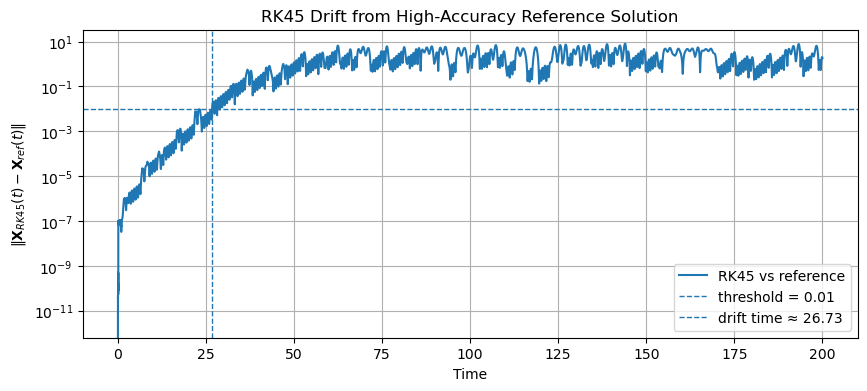

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(t_rk45, rk45_error, label="RK45 vs reference")

plt.axhline(
    drift_threshold,
    linestyle="--",
    linewidth=1,
    label=f"threshold = {drift_threshold}",
)

if drift_time is not None:
    plt.axvline(
        drift_time,
        linestyle="--",
        linewidth=1,
        label=f"drift time ≈ {drift_time:.2f}",
    )

plt.yscale("log")
plt.title("RK45 Drift from High-Accuracy Reference Solution")
plt.xlabel("Time")
plt.ylabel(r"$\|\mathbf{X}_{RK45}(t)-\mathbf{X}_{ref}(t)\|$")
plt.grid(True)
plt.legend()
plt.show()

This defines a practical prediction horizon: beyond $t \approx 26.7$, numerical trajectories are no longer reliable due to exponential error amplification.

Thus, long-term agreement is fundamentally impossible, regardless of solver accuracy.

### Divergence of Nearby Trajectories

For a chaotic system, nearby trajectories should separate:
$$
||\mathbf{X}_1(t)-\mathbf{X}_2(t)||~e^{\lambda t}
$$
where $\lambda>0$ indicates chaos

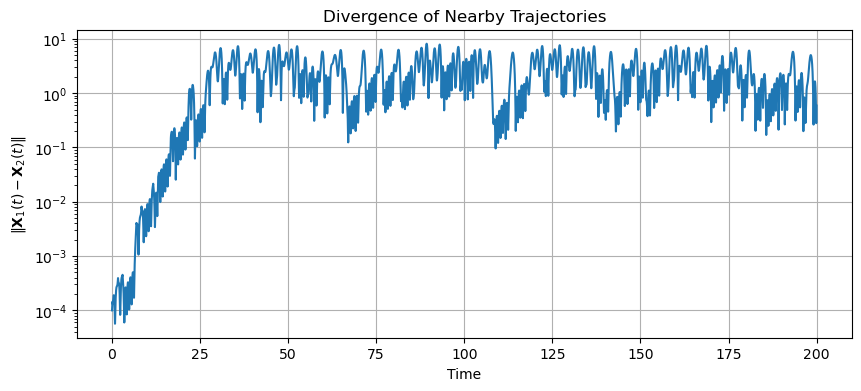

In [11]:
plt.figure(figsize=(10, 4))

plt.plot(
    t1,
    distance,
)

plt.yscale("log")

plt.title("Divergence of Nearby Trajectories")
plt.xlabel("Time")
plt.ylabel(r"$\|\mathbf{X}_1(t)-\mathbf{X}_2(t)\|$")

plt.grid(True)

plt.show()

### Unit Tests

Visual tests are needed, however further unit tests are also of note to verify the correctness of implementation at a more precise level. These tests verify diode symmetry and breakpoint behavior, solver shapes, boundedness, finite values, transient removal, short-time nearby trajectory agreement, and solver stability under stricter tolerances.

NOTE: Make sure to have `pytest` installed via `pip install pytest` or `conda install pytest`

In [12]:
!pytest comp_chua_test.py -q

........                                                                 [100%]
8 passed in 3.16s


### Sanity Check: Fractal Dimensions

A rough quantitative check may be made through a box-counting dimension estimate, where:
$$N(\varepsilon) \approx \varepsilon^{-D}$$
and the dimension is estimated from the slope of

$$
N(\epsilon) \sim \epsilon^{-D}
$$

so dimension $D$ is estimated from slope of

$$
\log N(\epsilon) \text{ versus } \log(\frac{1}{\epsilon})
$$
(Falconer, 2003).

Note that this is only a rough numerical sanity check, and not an exact invariant (Ott, 2002).

In [13]:
def box_count(points: np.ndarray, eps: float) -> int:
    """Count occupied boxes of side length eps."""
    mins = points.min(axis=0)
    shifted_points = points - mins
    box_indices = np.floor(shifted_points / eps).astype(int)
    unique_boxes = np.unique(box_indices, axis=0)

    return len(unique_boxes)


def box_count_dimension(
    points: np.ndarray,
    eps_values: np.ndarray,
) -> tuple[float, np.ndarray, np.ndarray]:
    """Estimate box-counting dimension using a log-log fit."""
    counts = []
    valid_eps = []

    for eps in eps_values:
        count = box_count(points, eps)

        if count > 0:
            counts.append(count)
            valid_eps.append(eps)

    log_inv_eps = np.log(1.0 / np.array(valid_eps))
    log_counts = np.log(np.array(counts))

    slope, _ = np.polyfit(log_inv_eps, log_counts, 1)

    return slope, log_inv_eps, log_counts


def estimate_dimension_from_solution(
    sol: np.ndarray,
    cut: int = TRANSIENT_CUT,
    step: int = 5,
    eps_values: np.ndarray | None = None,
) -> tuple[float, np.ndarray, np.ndarray]:
    """Estimate box-counting dimension from a Chua solution."""
    if eps_values is None:
        eps_values = np.linspace(0.08, 0.5, 10)

    x_tmp = sol[0][cut:]
    y_tmp = sol[1][cut:]
    z_tmp = sol[2][cut:]

    points = np.column_stack(
        [x_tmp, y_tmp, z_tmp]
    )[::step]

    dimension, log_inv_eps, log_counts = box_count_dimension(
        points,
        eps_values,
    )

    return dimension, log_inv_eps, log_counts

Estimated box-counting dimension: 1.735


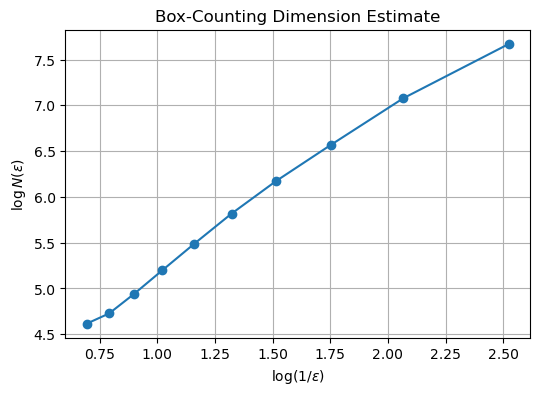

In [14]:
points = np.column_stack(
    [x_cut, y_cut, z_cut]
)[::5]

eps_values = np.linspace(0.08, 0.5, 10)

dimension, log_inv_eps, log_counts = box_count_dimension(
    points,
    eps_values,
)

print(
    f"Estimated box-counting dimension: "
    f"{dimension:.3f}"
)

plt.figure(figsize=(6, 4))

plt.plot(
    log_inv_eps,
    log_counts,
    "o-",
)

plt.xlabel(r"$\log(1/\epsilon)$")
plt.ylabel(r"$\log N(\epsilon)$")
plt.title("Box-Counting Dimension Estimate")

plt.grid(True)

plt.show()

In [15]:
t_lo, sol_lo = solve_chua(
    [0.7, 0.0, 0.0],
    rtol=1e-6,
    atol=1e-8,
)

t_hi, sol_hi = solve_chua(
    [0.7, 0.0, 0.0],
    rtol=1e-9,
    atol=1e-12,
)

t_rk, sol_rk = solve_chua(
    [0.7, 0.0, 0.0],
    method="RK45",
)

t_dp, sol_dp = solve_chua(
    [0.7, 0.0, 0.0],
    method="DOP853",
)

dim_rk45, *_ = estimate_dimension_from_solution(sol_rk)
dim_dop853, *_ = estimate_dimension_from_solution(sol_dp)
dim_loose, *_ = estimate_dimension_from_solution(sol_lo)
dim_strict, *_ = estimate_dimension_from_solution(sol_hi)

print(
    f"Box-count dimension (RK45):   {dim_rk45:.3f}"
)
print(
    f"Box-count dimension (DOP853): {dim_dop853:.3f}"
)
print(
    f"Box-count dimension (loose):  {dim_loose:.3f}"
)
print(
    f"Box-count dimension (strict): {dim_strict:.3f}"
)

Box-count dimension (RK45):   1.735
Box-count dimension (DOP853): 1.739
Box-count dimension (loose):  1.708
Box-count dimension (strict): 1.700


## Interpretations

The computations above determine the following:
1. The time series is bounded, yet irregular, which indicates that the system does not diverge while staying non-periodic, consistent with chaotic dynamics where trajectories remain bounded to an attractor.
2. The reconstructed attractor is three-dimensional and non-periodic, in agreement with the Poincaré-Bendixson theorem stating that chaos cannot happen in bounded two-dimensional systems (Strogatz, 2015).
3. Nearby trajectories initially remain close, confirming that RK45 accurately resolves short-time dynamics before exponential divergence dominates.
4. Exponential divergence of nearby trajectories confirms sensitive dependence on initial conditions, which is a defining feature of chaos, and explains why long-term prediction is unreliable regardless of solver accuracy.

A positive Lyapunov exponent implies that long-term prediction is fundamentally limited, not by numerical methods, but by the system’s intrinsic dynamics.

5. The drift analysis shows that RK45 remains close to a high-accuracy reference solution up to a finite time horizon ($t = 26.73$), after which numerical errors grow exponentially. This is not a failure of the numerical method though, rather a consequence of the system's chaotic nature.
6. The box-counting dimension estimate remains consistent across solver methods and tolerances, which indicates that the attractor's structure is robust and not an artifact of discretization.

## Citations

Chua, L. O. (1992). The genesis of Chua's circuit.

Dormand, J. R., & Prince, P. J. (1980). A family of embedded Runge-Kutta formulae.

Hairer, E., Nørsett, S. P., & Wanner, G. (1993). Solving Ordinary Differential Equations I.

Strogatz, S. H. (2015). Nonlinear Dynamics and Chaos.

Ott, E. (2002). Chaos in Dynamical Systems.

Falconer, K. (2003). Fractal Geometry.

Butcher, J. C. (2016). Numerical Methods for ODEs.

Matsumoto, T. (1984). A chaotic attractor from Chua's circuit.